# Exploratory Data Analysis (EDA)

The goal of this stage is to explore customer behavior, identify patterns related to churn, and generate insights that can improve feature engineering and model performance.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8, 5)

# Display formatting
from IPython.core.display import HTML
HTML("""
<style>
.dataframe table, .dataframe th, .dataframe td { font-size: 12px; }
div.output_scroll { overflow-x: auto; }
</style>
""")

In [2]:
data = pd.read_csv("telco_cleaned.csv")
data.head()

,gender,age,under_30,senior_citizen,married,dependents,number_of_dependents,city,zip_code,latitude,longitude,population,referred_a_friend,number_of_referrals,tenure_in_months,offer,phone_service,avg_monthly_long_distance_charges,multiple_lines,internet_service,internet_type,avg_monthly_gb_download,online_security,online_backup,device_protection_plan,premium_tech_support,streaming_tv,streaming_movies,streaming_music,unlimited_data,contract,paperless_billing,payment_method,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,satisfaction_score,churn_label
0,Male,78,No,Yes,No,No,0,Los Angeles,90022,34.023810,-118.156582,68701,No,0,1,No Offer,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Yes
1,Female,74,No,Yes,Yes,Yes,1,Los Angeles,90063,34.044271,-118.185237,55668,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Yes
2,Male,71,No,Yes,No,Yes,3,Los Angeles,90065,34.108833,-118.229715,47534,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Yes
3,Female,78,No,Yes,Yes,Yes,1,Inglewood,90303,33.936291,-118.332639,27778,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Yes
4,Female,80,No,Yes,Yes,Yes,1,Whittier,90602,33.972119,-118.020188,26265,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Yes


In [3]:
data.shape

(7043, 41)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             7043 non-null   object 
 1   age                                7043 non-null   int64  
 2   under_30                           7043 non-null   object 
 3   senior_citizen                     7043 non-null   object 
 4   married                            7043 non-null   object 
 5   dependents                         7043 non-null   object 
 6   number_of_dependents               7043 non-null   int64  
 7   city                               7043 non-null   object 
 8   zip_code                           7043 non-null   int64  
 9   latitude                           7043 non-null   float64
 10  longitude                          7043 non-null   float64
 11  population                         7043 non-null   int64

## Dataset Overview

Before starting the analysis, we perform a quick overview of the cleaned dataset to verify its structure, dimensions, and data types.

## EDA Roadmap

We will explore:

1. Target variable distribution
2. Numerical features vs churn
3. Categorical features vs churn
4. Correlation analysis
5. Business insights and key findings

In [5]:
data["churn_label"].value_counts()

churn_label
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
round(
    data["churn_label"].value_counts(normalize=True) * 100,
    2
)

churn_label
No     73.46
Yes    26.54
Name: proportion, dtype: float64

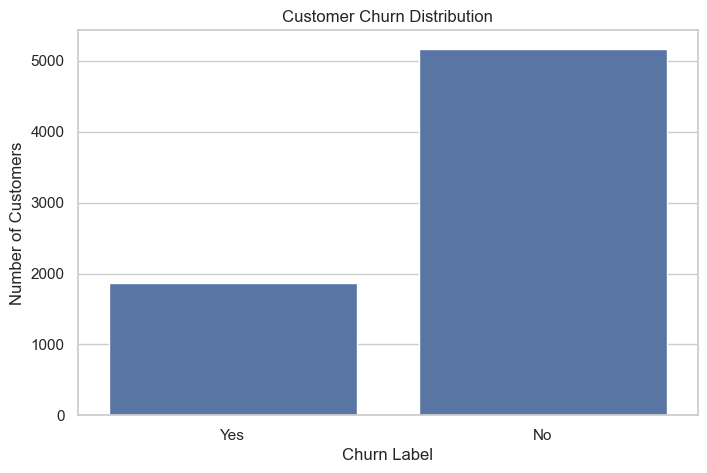

In [7]:
sns.countplot(
    data=data,
    x="churn_label"
)

plt.title("Customer Churn Distribution")

plt.xlabel("Churn Label")
plt.ylabel("Number of Customers")

plt.show()

### Insight

- The dataset is moderately imbalanced (73% non-churn vs 27% churn).
- This means accuracy alone can be misleading.
- The business focus is on identifying churned customers (minority class).
- Therefore, recall and F1-score will be more appropriate evaluation metrics.

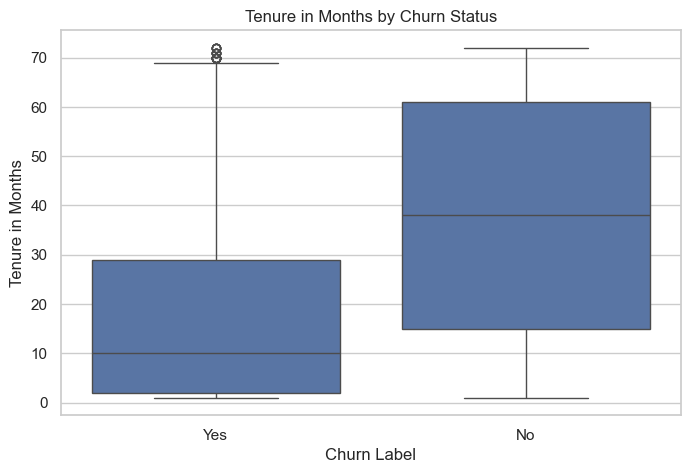

In [8]:
sns.boxplot(
    data=data,
    x="churn_label",
    y="tenure_in_months"
)

plt.title("Tenure in Months by Churn Status")

plt.xlabel("Churn Label")
plt.ylabel("Tenure in Months")

plt.show()

In [9]:
data.groupby("churn_label")["tenure_in_months"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
churn_label,,,,,,,,
No,5174.0,37.59,24.09,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


### Insight

- Customers who churned tend to have significantly shorter tenures than customers who stayed.
- The median tenure for churned customers is 10 months, compared to 38 months for retained customers.
- Approximately 75% of churned customers leave within the first 29 months.
- Although some long-term customers still churn, customer tenure appears to be a strong predictor of churn.
- These findings suggest that retention efforts should focus on customers during their early lifecycle.

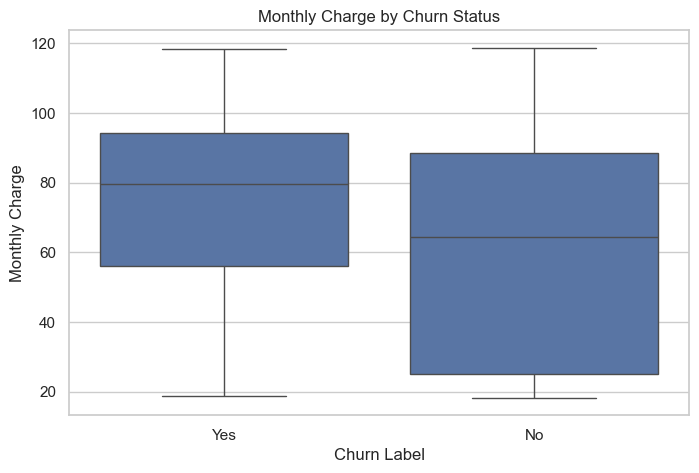

In [10]:
sns.boxplot(
    data=data,
    x="churn_label",
    y="monthly_charge"
)

plt.title("Monthly Charge by Churn Status")

plt.xlabel("Churn Label")
plt.ylabel("Monthly Charge")

plt.show()

In [11]:
data.groupby("churn_label")["monthly_charge"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
churn_label,,,,,,,,
No,5174.0,61.27,31.09,18.25,25.10,64.43,88.4,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.2,118.35


### Insight

- Customers who churned tend to have higher monthly charges than retained customers.
- The median monthly charge for churned customers is $79.65, compared to $64.43 for retained customers.
- Higher monthly charges appear to be associated with increased churn risk.
- However, there is substantial overlap between the two groups, indicating that monthly charges alone are insufficient to explain churn behavior.
- Additional factors such as contract type, internet service, and customer satisfaction may influence this relationship.

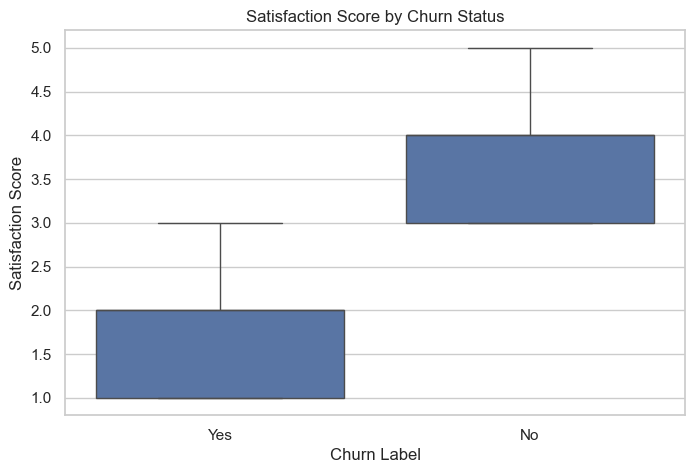

In [12]:
sns.boxplot(
    data=data,
    x="churn_label",
    y="satisfaction_score"
)

plt.title("Satisfaction Score by Churn Status")

plt.xlabel("Churn Label")
plt.ylabel("Satisfaction Score")

plt.show()

In [13]:
data.groupby("churn_label")["satisfaction_score"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
churn_label,,,,,,,,
No,5174.0,3.79,0.78,3.0,3.0,4.0,4.0,5.0
Yes,1869.0,1.74,0.81,1.0,1.0,2.0,2.0,3.0


### Insight

- Customer Satisfaction Score shows a very strong separation between churned and retained customers.
- 75% of churned customers have a satisfaction score of 2 or lower.
- 75% of retained customers have a satisfaction score of 3 or higher.
- This is one of the strongest predictors of churn observed so far.
- Customer satisfaction appears to be a critical driver of customer retention.

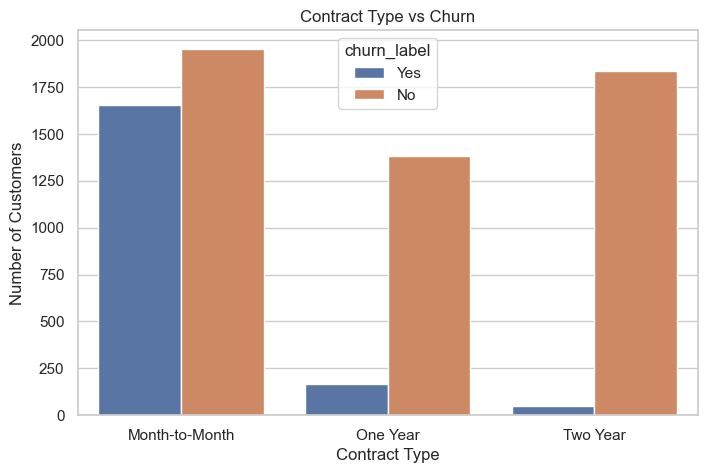

In [14]:
sns.countplot(
    data=data,
    x="contract",
    hue="churn_label"
)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [15]:
contract_churn = pd.crosstab(
    data["contract"],
    data["churn_label"],
    normalize="index"
) * 100

contract_churn.round(2)

churn_label,No,Yes
contract,,
Month-to-Month,54.16,45.84
One Year,89.29,10.71
Two Year,97.45,2.55


### Insight

- Contract type has a very strong relationship with customer churn.
- Month-to-Month contracts show the highest churn rate (~46%), indicating low customer commitment.
- One Year and Two Year contracts significantly reduce churn to ~11% and ~2.5% respectively.
- This suggests that contract duration is one of the most influential factors in customer retention.
- Encouraging long-term contracts could be a key strategy to reduce churn.

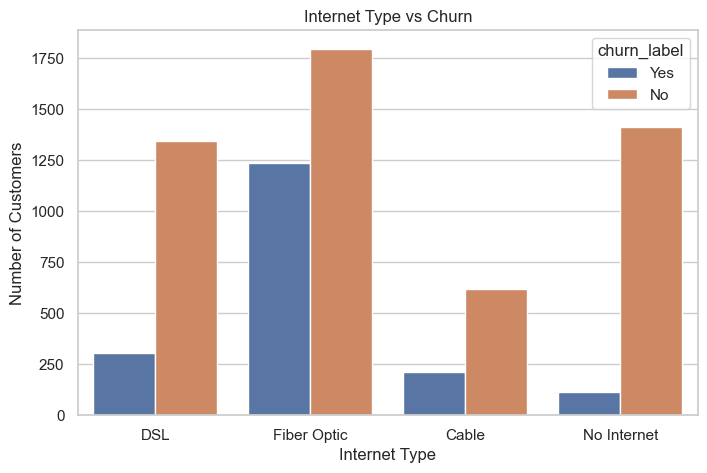

In [16]:
sns.countplot(
    data=data,
    x="internet_type",
    hue="churn_label"
)

plt.title("Internet Type vs Churn")
plt.xlabel("Internet Type")
plt.ylabel("Number of Customers")

plt.show()

In [17]:
internet_churn = pd.crosstab(
    data["internet_type"],
    data["churn_label"],
    normalize="index"
) * 100

internet_churn.round(2)

churn_label,No,Yes
internet_type,,
Cable,74.34,25.66
DSL,81.42,18.58
Fiber Optic,59.28,40.72
No Internet,92.60,7.40


### Insight

- Fiber Optic customers exhibit the highest churn rate (~40.7%), significantly higher than other internet types.
- DSL customers show moderate churn (~18.6%), while Cable and No Internet users have relatively low churn rates.
- This suggests that internet service type is strongly associated with churn behavior.
- The high churn in Fiber Optic may be related to customer expectations, pricing, or service quality perception.
- Further analysis is required to understand interactions with monthly charges and satisfaction levels.

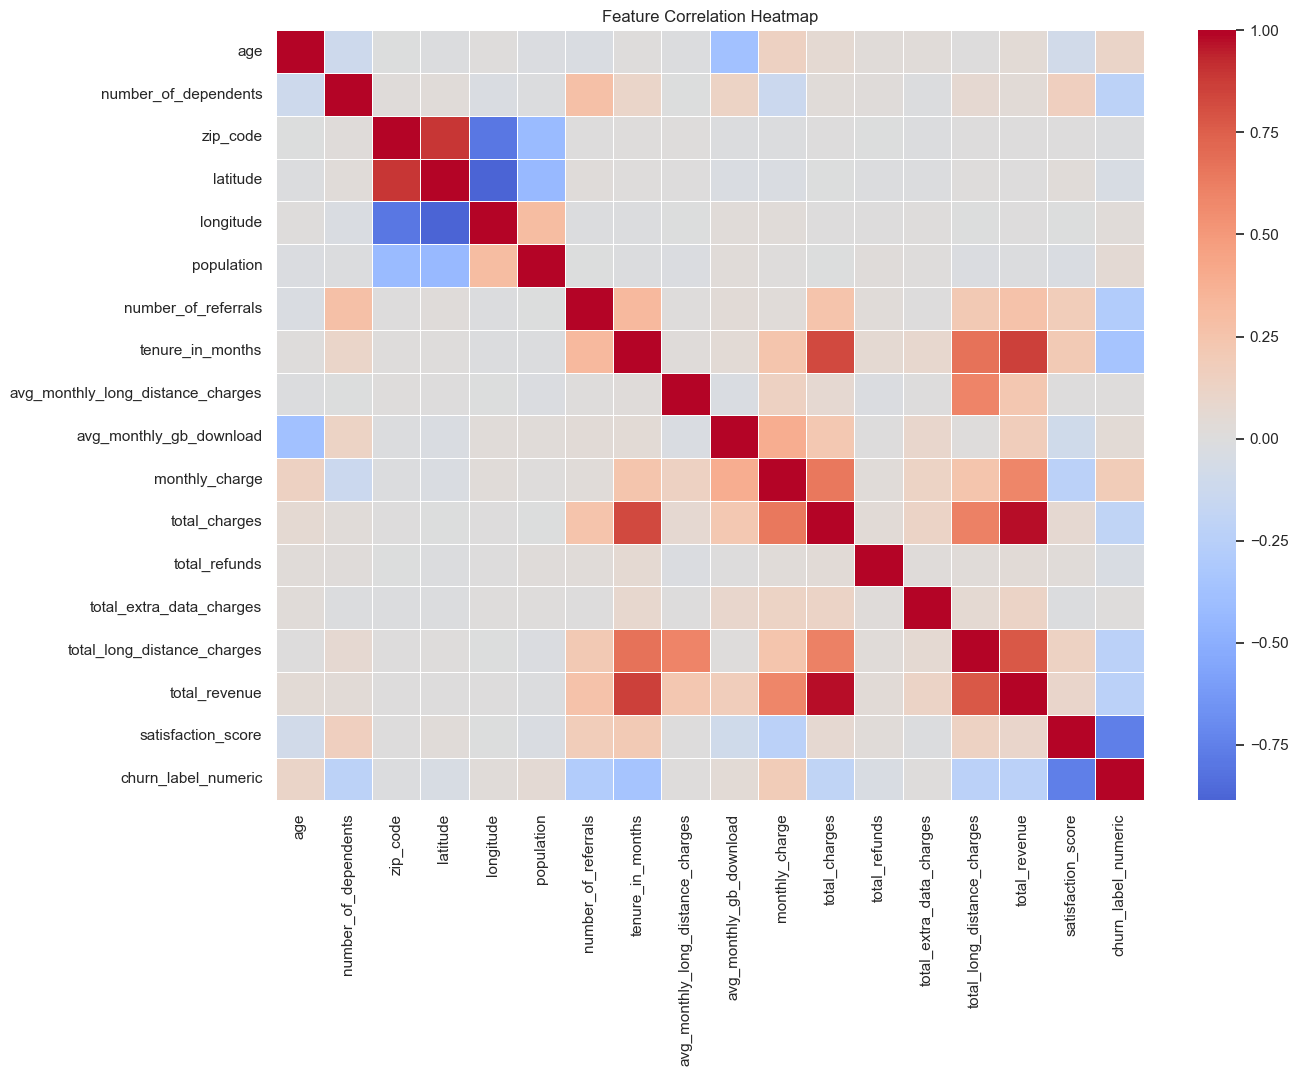

In [18]:
eda_data = data.copy()

eda_data["churn_label_numeric"] = (
    eda_data["churn_label"]
    .map({"Yes": 1, "No": 0})
)
corr_matrix = eda_data.select_dtypes(
    include=["int64","float64"]
).corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

### 🔍 Insight: Feature Correlation Analysis

- Strong correlations exist among revenue-related variables such as Total Charges, Total Revenue, and Tenure in Months.

- Customers with higher Satisfaction Scores tend to have significantly lower churn rates.

- Longer customer relationships (Tenure in Months) and a higher number of referrals are associated with lower churn probability.

- Monthly Charge shows a weak positive relationship with churn, suggesting that customers with higher monthly costs are slightly more likely to leave.

- Geographic features such as Zip Code, Latitude, and Longitude exhibit minimal correlation with churn.

- The heatmap also reveals potential multicollinearity among some financial variables, which should be considered during feature selection and model interpretation.

In [19]:
# Correlation with target
corr_with_churn = corr_matrix["churn_label_numeric"].sort_values(ascending=False)

corr_with_churn

churn_label_numeric                  1.000000
monthly_charge                       0.193356
age                                  0.115760
population                           0.051649
avg_monthly_gb_download              0.048868
longitude                            0.024052
avg_monthly_long_distance_charges    0.008120
total_extra_data_charges             0.007139
zip_code                            -0.016289
total_refunds                       -0.033709
latitude                            -0.041546
total_charges                       -0.198546
number_of_dependents                -0.218780
total_revenue                       -0.223003
total_long_distance_charges         -0.223756
number_of_referrals                 -0.286540
tenure_in_months                    -0.352861
satisfaction_score                  -0.754649
Name: churn_label_numeric, dtype: float64

### 🔍 Insight: Key Drivers of Customer Churn

- Satisfaction Score has the strongest negative correlation with churn (-0.75), indicating that dissatisfied customers are significantly more likely to leave.

- Tenure in Months (-0.35) suggests that newer customers have a higher risk of churn compared to long-term customers.

- Number of Referrals (-0.29) is negatively associated with churn, implying that engaged customers who refer others are more likely to remain loyal.

- Revenue-related features, including Total Revenue, Total Charges, and Total Long Distance Charges, show moderate negative correlations with churn, indicating that higher-value customers tend to stay longer.

- Monthly Charge (0.19) has a weak positive correlation with churn, suggesting that higher monthly costs may slightly increase churn risk.

- Demographic and geographic variables demonstrate minimal correlations with churn and may contribute less predictive power.

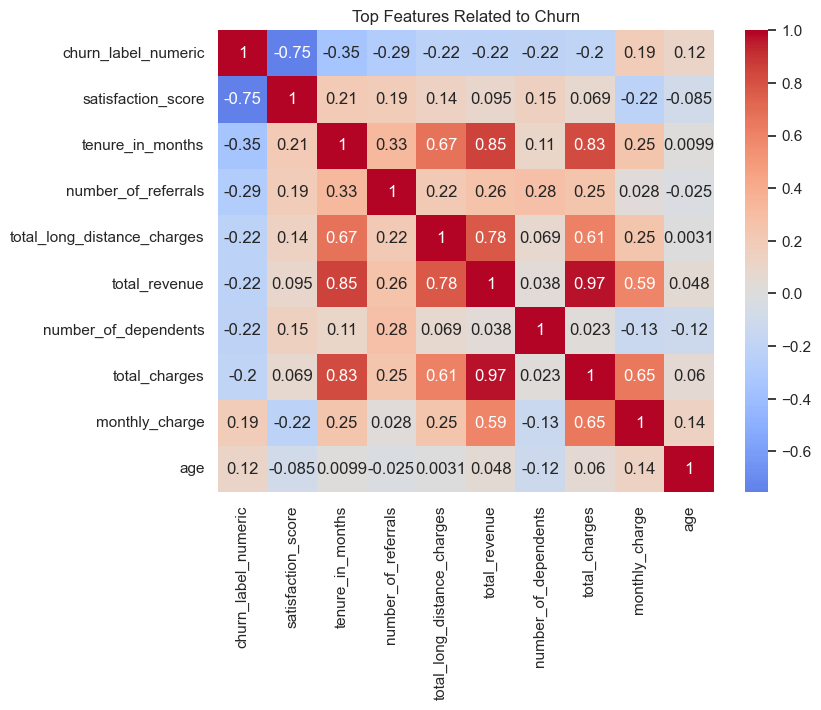

In [20]:
top_features = corr_with_churn.sort_values(key=abs, ascending=False).head(10).index

plt.figure(figsize=(8,6))

sns.heatmap(
    eda_data[top_features].corr(),
    cmap="coolwarm",
    center=0,
    annot=True
)

plt.title("Top Features Related to Churn")
plt.show()

### 🔍 Insight: Top Features Associated with Churn

- Customer satisfaction is the strongest predictor of churn.

- Customer tenure and referral behavior are important indicators of loyalty.

- Financial engagement metrics contribute to churn prediction but are less influential than satisfaction and tenure.

- Churn appears to be driven primarily by customer experience and engagement rather than demographic or geographic characteristics.

## Key Business Findings

1. Customer satisfaction is the strongest indicator of churn.

2. New customers are significantly more likely to leave than long-term customers.

3. Month-to-Month contracts represent the highest churn risk segment.

4. Fiber Optic customers exhibit substantially higher churn rates compared to other internet types.

5. Customers who refer others tend to remain loyal and have lower churn rates.

6. Higher monthly charges are associated with increased churn probability.

7. Customer retention initiatives should focus on early lifecycle customers and high-cost plans.

## Final Summary

The exploratory data analysis revealed several strong patterns related to customer churn.

Key findings include:

- Satisfaction Score is the strongest churn indicator.
- Customer tenure has a substantial impact on retention.
- Contract type plays a major role in churn behavior.
- Fiber Optic customers exhibit elevated churn rates.
- Revenue-related variables correlate strongly with customer loyalty.
- Geographic features contribute little predictive value.

These findings will guide the Feature Engineering stage and help identify the most relevant variables for predictive modeling.